<a href="https://colab.research.google.com/github/04suman/sumanamit/blob/main/97_percent_simple_Binary_KOA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import PIL
import cv2
import tensorflow as tf
from tensorflow import keras

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os


In [ ]:
good=os.listdir("/content/drive/MyDrive/mydata/train/0/")

In [ ]:
b4=os.listdir("/content/drive/MyDrive/mydata/train/3/")


In [ ]:
bad=b4[:1000]

In [ ]:
x1=[]
y1=[]
for i in good[:1000]:
    x=cv2.imread(str("/content/drive/MyDrive/mydata/train/0/"+i))
    x1.append(x)
    y1.append(1)


In [ ]:
print(x1[1])

[[[135 135 135]
  [134 134 134]
  [135 135 135]
  ...
  [180 180 180]
  [179 179 179]
  [176 176 176]]

 [[135 135 135]
  [135 135 135]
  [135 135 135]
  ...
  [180 180 180]
  [179 179 179]
  [176 176 176]]

 [[135 135 135]
  [136 136 136]
  [136 136 136]
  ...
  [179 179 179]
  [178 178 178]
  [177 177 177]]

 ...

 [[ 67  67  67]
  [ 68  68  68]
  [ 69  69  69]
  ...
  [170 170 170]
  [168 168 168]
  [164 164 164]]

 [[ 66  66  66]
  [ 67  67  67]
  [ 70  70  70]
  ...
  [168 168 168]
  [166 166 166]
  [164 164 164]]

 [[ 67  67  67]
  [ 68  68  68]
  [ 71  71  71]
  ...
  [168 168 168]
  [166 166 166]
  [163 163 163]]]


In [ ]:
x2=[]
y2=[]
for i in bad[:1000]:
    x=cv2.imread(str("/content/drive/MyDrive/mydata/train/3/"+i))
    x2.append(x)
    y2.append(0)

xdata=x1+x2
ydata=y1+y2

In [ ]:

xdata=np.array(xdata)
ydata=np.array(ydata)
xdata=xdata/255
ydata

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
model=keras.Sequential([
                        keras.layers.Conv2D(32,3,padding='same',activation='relu'),
                        keras.layers.MaxPooling2D((2,2)),
                        keras.layers.Dropout(0.2),
                        keras.layers.Conv2D(64,3,padding='same',activation='relu'),
                        keras.layers.MaxPooling2D((2,2)),
                        keras.layers.Conv2D(128,3,padding='same',activation='relu'),
                        keras.layers.MaxPooling2D((2,2)),
                        keras.layers.Flatten(),
                        keras.layers.Dense(128,activation='relu'),
                        keras.layers.Dense(64,activation='relu'),
                        keras.layers.Dense(32,activation='relu'),
                        keras.layers.Dense(2,activation='sigmoid'),
                       ])

In [ ]:
model.compile(optimizer='adam',loss='SparseCategoricalCrossentropy',metrics=['accuracy'])

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(xdata,ydata,test_size=0.2,random_state=43)


In [ ]:
history=model.fit(xtrain,ytrain,epochs=30)

Epoch 1/30
44/44 [==============================] - 4s 81ms/step - loss: 0.2038 - accuracy: 0.9224
Epoch 2/30
44/44 [==============================] - 4s 81ms/step - loss: 0.1906 - accuracy: 0.9181
Epoch 3/30
44/44 [==============================] - 4s 86ms/step - loss: 0.1823 - accuracy: 0.9260
Epoch 4/30
44/44 [==============================] - 4s 84ms/step - loss: 0.1504 - accuracy: 0.9381
Epoch 5/30
44/44 [==============================] - 4s 82ms/step - loss: 0.2163 - accuracy: 0.9160
Epoch 6/30
44/44 [==============================] - 4s 81ms/step - loss: 0.2203 - accuracy: 0.9125
Epoch 7/30
44/44 [==============================] - 4s 85ms/step - loss: 0.1375 - accuracy: 0.9495
Epoch 8/30
44/44 [==============================] - 4s 84ms/step - loss: 0.1135 - accuracy: 0.9530
Epoch 9/30
44/44 [==============================] - 4s 81ms/step - loss: 0.1136 - accuracy: 0.9544
Epoch 10/30
44/44 [==============================] - 4s 81ms/step - loss: 0.1440 - accuracy: 0.9402
Epoch 11/

In [ ]:
model.evaluate(xtest,ytest)

11/11 [==============================] - 0s 31ms/step - loss: 0.2939 - accuracy: 0.9233


[0.2939143478870392, 0.9232954382896423]

In [ ]:
ypred=model.predict(xtest)
ypred[10:15]

11/11 [==============================] - 0s 28ms/step


array([[0.01313755, 0.9549631 ],
       [0.0111703 , 0.9480221 ],
       [0.00789063, 0.9687243 ],
       [0.97529197, 0.00144184],
       [0.0679746 , 0.71482587]], dtype=float32)

In [ ]:
yp=[np.argmax(i) for i in ypred]

In [ ]:
yp[0:15]

[1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1]

In [ ]:
ytest[0:15]

array([1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(ytest,yp)*100

92.32954545454545

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
cm = confusion_matrix(ytest, yp)

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm
...                               )

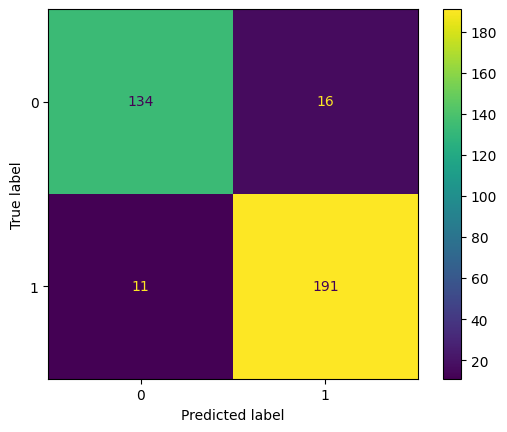

In [ ]:
disp.plot()

In [ ]:
from sklearn.metrics import precision_score, \
    recall_score, confusion_matrix, classification_report, \
    accuracy_score, f1_score

In [ ]:
print ('F1 score:', f1_score(ytest, yp)*100)
print ('Recall:', recall_score(ytest, yp)*100)
print ('Precision:', precision_score(ytest, yp)*100)
print ('\n clasification report:\n', classification_report(ytest, yp)*100)
print ('\n confussion matrix:\n',confusion_matrix(ytest, yp)*100)

F1 score: 93.39853300733495
Recall: 94.55445544554455
Precision: 92.27053140096618

 clasification report:
               precision    recall  f1-score   support

           0       0.92      0.89      0.91       150
           1       0.92      0.95      0.93       202

    accuracy                           0.92       352
   macro avg       0.92      0.92      0.92       352
weighted avg       0.92      0.92      0.92       352
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       150
           1       0.92      0.95      0.93       202

    accuracy                           0.92       352
   macro avg       0.92      0.92      0.92       352
weighted avg       0.92      0.92      0.92       352
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       150
           1       0.92      0.95      0.93       202

    accuracy                           0.92       352
   macro avg       0.9

In [ ]:
 import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

0.9194389438943894


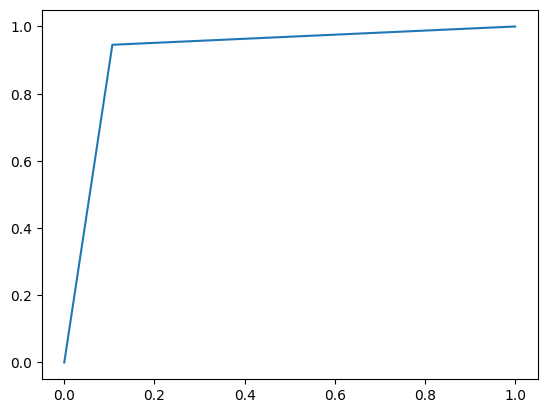

In [ ]:
val1,val2,val3=roc_curve(ytest,yp)
auc_val=auc(val1,val2)
# summarize scores
plt.plot(val1,val2)
print(auc_val)

In [ ]:

lossvalue=history.history['loss']
accvalue=history.history['accuracy']


In [ ]:
li=[i for i in range(30)]

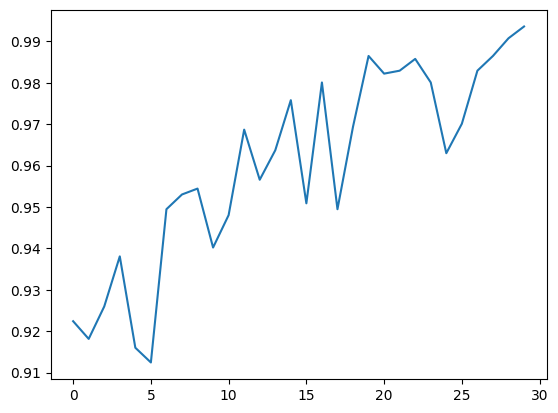

In [ ]:
plt.plot(li,accvalue)

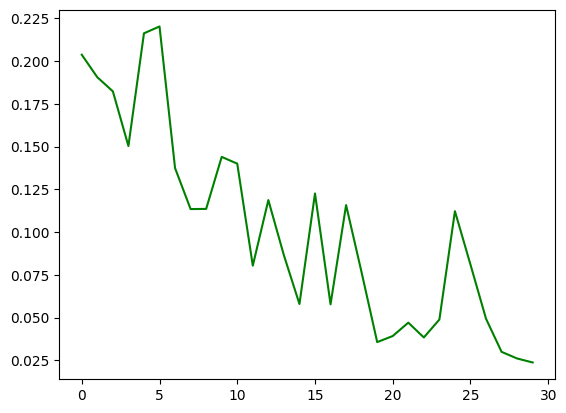

In [ ]:
plt.plot(li,lossvalue, color='green')

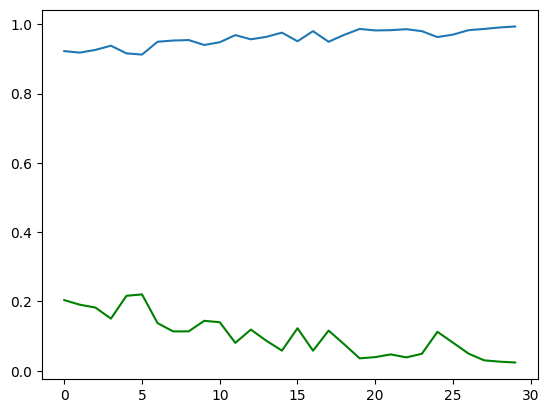

In [ ]:
plt.plot(li,accvalue)
plt.plot(li,lossvalue, color='green')